# Introduction

Google Trends gives us an estimate of search volume. Let's explore if search popularity relates to other kinds of data. Perhaps there are patterns in Google's search volume and the price of Bitcoin or a hot stock like Tesla. Perhaps search volume for the term "Unemployment Benefits" can tell us something about the actual unemployment rate? 

Data Sources: <br>
<ul>
<li> <a href="https://fred.stlouisfed.org/series/UNRATE/">Unemployment Rate from FRED</a></li>
<li> <a href="https://trends.google.com/trends/explore">Google Trends</a> </li>  
<li> <a href="https://finance.yahoo.com/quote/TSLA/history?p=TSLA">Yahoo Finance for Tesla Stock Price</a> </li>    
<li> <a href="https://finance.yahoo.com/quote/BTC-USD/history?p=BTC-USD">Yahoo Finance for Bitcoin Stock Price</a> </li>
</ul>

# Import Statements

In [100]:
import pandas
from matplotlib import pyplot
from matplotlib import dates

# Read the Data

Download and add the .csv files to the same folder as your notebook.

In [101]:
df_tesla = pandas.read_csv('TESLA Search Trend vs Price.csv')

df_btc_search = pandas.read_csv('Bitcoin Search Trend.csv')
df_btc_price = pandas.read_csv('Daily Bitcoin Price.csv')

df_unemployment = pandas.read_csv('UE Benefits Search vs UE Rate 2004-19.csv')

# Data Exploration

### Tesla

**Challenge**: <br>
<ul>
<li>What are the shapes of the dataframes? </li>
<li>How many rows and columns? </li>
<li>What are the column names? </li>
<li>Complete the f-string to show the largest/smallest number in the search data column</li> 
<li>Try the <code>.describe()</code> function to see some useful descriptive statistics</li>
<li>What is the periodicity of the time series data (daily, weekly, monthly)? </li>
<li>What does a value of 100 in the Google Trend search popularity actually mean?</li>
</ul>

In [102]:
# tesla
# What are the shapes of the dataframes? 
# How many rows and columns
df_tesla
df_tesla.shape
df_btc_price
df_btc_price.shape
df_btc_search
df_btc_search.shape
df_unemployment
df_unemployment.shape

(181, 3)

In [103]:
# What are the column names?
# Bitcoin price

df_tesla.columns
df_btc_price.columns
df_btc_search.columns
df_unemployment.columns

Index(['MONTH', 'UE_BENEFITS_WEB_SEARCH', 'UNRATE'], dtype='str')

In [104]:
# Complete the f-string to show the largest/smallest number in the search data column
print(f'Largest value for Tesla in Web Search: {df_tesla['TSLA_WEB_SEARCH'].max()}')
print(f'Smallest value for Tesla in Web Search: {df_tesla.TSLA_WEB_SEARCH.min()}')

Largest value for Tesla in Web Search: 31
Smallest value for Tesla in Web Search: 2


In [105]:
# Try the <code>.describe()</code> function to see some useful descriptive statistics
df_tesla.describe()

,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
count,124.000000,124.000000
mean,8.725806,50.962145
std,5.870332,65.908389
min,2.000000,3.896000
25%,3.750000,7.352500
50%,8.000000,44.653000
75%,12.000000,58.991999
max,31.000000,498.320007


In [106]:
# What is the periodicity of the time series data (daily, weekly, monthly)?
df_tesla.MONTH

0      2010-06-01
1      2010-07-01
2      2010-08-01
3      2010-09-01
4      2010-10-01
          ...    
119    2020-05-01
120    2020-06-01
121    2020-07-01
122    2020-08-01
123    2020-09-01
Name: MONTH, Length: 124, dtype: str

### Unemployment Data

In [107]:
df_unemployment.head()

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7
1,2004-02,33,5.6
2,2004-03,25,5.8
3,2004-04,29,5.6
4,2004-05,23,5.6


In [108]:
print('Largest value for "Unemployemnt Benefits" '
      f'in Web Search: {df_unemployment.UE_BENEFITS_WEB_SEARCH.max()}')

Largest value for "Unemployemnt Benefits" in Web Search: 100


### Bitcoin

In [109]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0


In [110]:
df_btc_search.head()

,MONTH,BTC_NEWS_SEARCH
0,2014-09,5
1,2014-10,4
2,2014-11,4
3,2014-12,4
4,2015-01,5


In [111]:
print(f'largest BTC News Search: {df_btc_search.BTC_NEWS_SEARCH.max()}')

largest BTC News Search: 100


# Data Cleaning

### Check for Missing Values

**Challenge**: Are there any missing values in any of the dataframes? If so, which row/rows have missing values? How many missing values are there?

In [112]:
print(f'Missing values for Tesla?: {df_tesla.isna().value_counts()}')
print(f'Missing values for U/E?: {df_unemployment.isna().value_counts()}')
print(f'Missing values for BTC Search?: {df_btc_search.isna().value_counts()}')
print(df_tesla.shape)
print(df_unemployment.shape)
print(df_btc_search.shape)

print(df_btc_price.isna().value_counts())
print(df_btc_price.shape)


Missing values for Tesla?: MONTH  TSLA_WEB_SEARCH  TSLA_USD_CLOSE
False  False            False             124
Name: count, dtype: int64
Missing values for U/E?: MONTH  UE_BENEFITS_WEB_SEARCH  UNRATE
False  False                   False     181
Name: count, dtype: int64
Missing values for BTC Search?: MONTH  BTC_NEWS_SEARCH
False  False              73
Name: count, dtype: int64
(124, 3)
(181, 3)
(73, 2)
DATE   CLOSE  VOLUME
False  False  False     2203
       True   True         1
Name: count, dtype: int64
(2204, 3)


### Finding The Missing Values

In [113]:
print(f'Missing values for BTC price?: {df_btc_price.isna().values.any()}')

Missing values for BTC price?: True


In [114]:
print(f'Number of missing values: {df_btc_price.isna().values.sum()}')
df_btc_price[df_btc_price.VOLUME.isna()]

Number of missing values: 2


,DATE,CLOSE,VOLUME
2148,2020-08-04,NaN,NaN


**Challenge**: Remove any missing values that you found. 

In [115]:
df_btc_price.dropna(inplace=True)
df_btc_price.value_counts()

DATE        CLOSE         VOLUME      
2014-09-17  457.334015    2.105680e+07    1
2014-09-18  424.440002    3.448320e+07    1
2014-09-19  394.795990    3.791970e+07    1
2014-09-20  408.903992    3.686360e+07    1
2014-09-21  398.821014    2.658010e+07    1
                                         ..
2020-09-24  10745.548828  2.301754e+10    1
2020-09-25  10702.290039  2.123255e+10    1
2020-09-26  10754.437500  1.810501e+10    1
2020-09-27  10774.426758  1.801688e+10    1
2020-09-28  10912.536133  2.122653e+10    1
Name: count, Length: 2203, dtype: int64

### Convert Strings to DateTime Objects

**Challenge**: Check the data type of the entries in the DataFrame MONTH or DATE columns. Convert any strings in to Datetime objects. Do this for all 4 DataFrames. Double check if your type conversion was successful.

In [116]:
print(type(df_tesla.MONTH[1]))
df_tesla.MONTH = pandas.to_datetime(df_tesla.MONTH)
print(type(df_tesla.MONTH[1]))


<class 'str'>
<class 'pandas.Timestamp'>


In [117]:
print(type(df_unemployment.MONTH[0]))
df_unemployment.MONTH = pandas.to_datetime(df_unemployment.MONTH)
print(type(df_unemployment.MONTH[0]))

<class 'str'>
<class 'pandas.Timestamp'>


In [118]:
print(type(df_btc_search.MONTH[0]))
df_btc_search.MONTH = pandas.to_datetime(df_btc_search.MONTH)
print(type(df_btc_search.MONTH[0]))

print(type(df_btc_price.DATE[0]))
df_btc_price.DATE = pandas.to_datetime(df_btc_price.DATE)
print(type(df_btc_price.DATE[0]))



<class 'str'>
<class 'pandas.Timestamp'>
<class 'str'>
<class 'pandas.Timestamp'>


### Converting from Daily to Monthly Data

[Pandas .resample() documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.resample.html) <br>

In [119]:
df_btc_monthly_price = df_btc_price.resample('ME', on='DATE').last()
df_btc_monthly_price.head()

# If we wanted the average price over the course of the month, we could use something like:
df_btc_monthly_price = df_btc_price.resample('ME', on='DATE').mean()
df_btc_monthly_price.head()

,CLOSE,VOLUME
DATE,,
2014-09-30,407.182428,2.934864e+07
2014-10-31,364.148873,2.912885e+07
2014-11-30,366.099799,2.199111e+07
2014-12-31,341.267871,1.784201e+07
2015-01-31,248.782547,3.544555e+07


In [120]:
print(df_btc_monthly_price.shape)
print(df_btc_search.shape)

(73, 2)
(73, 2)


# Data Visualisation

### Notebook Formatting & Style Helpers

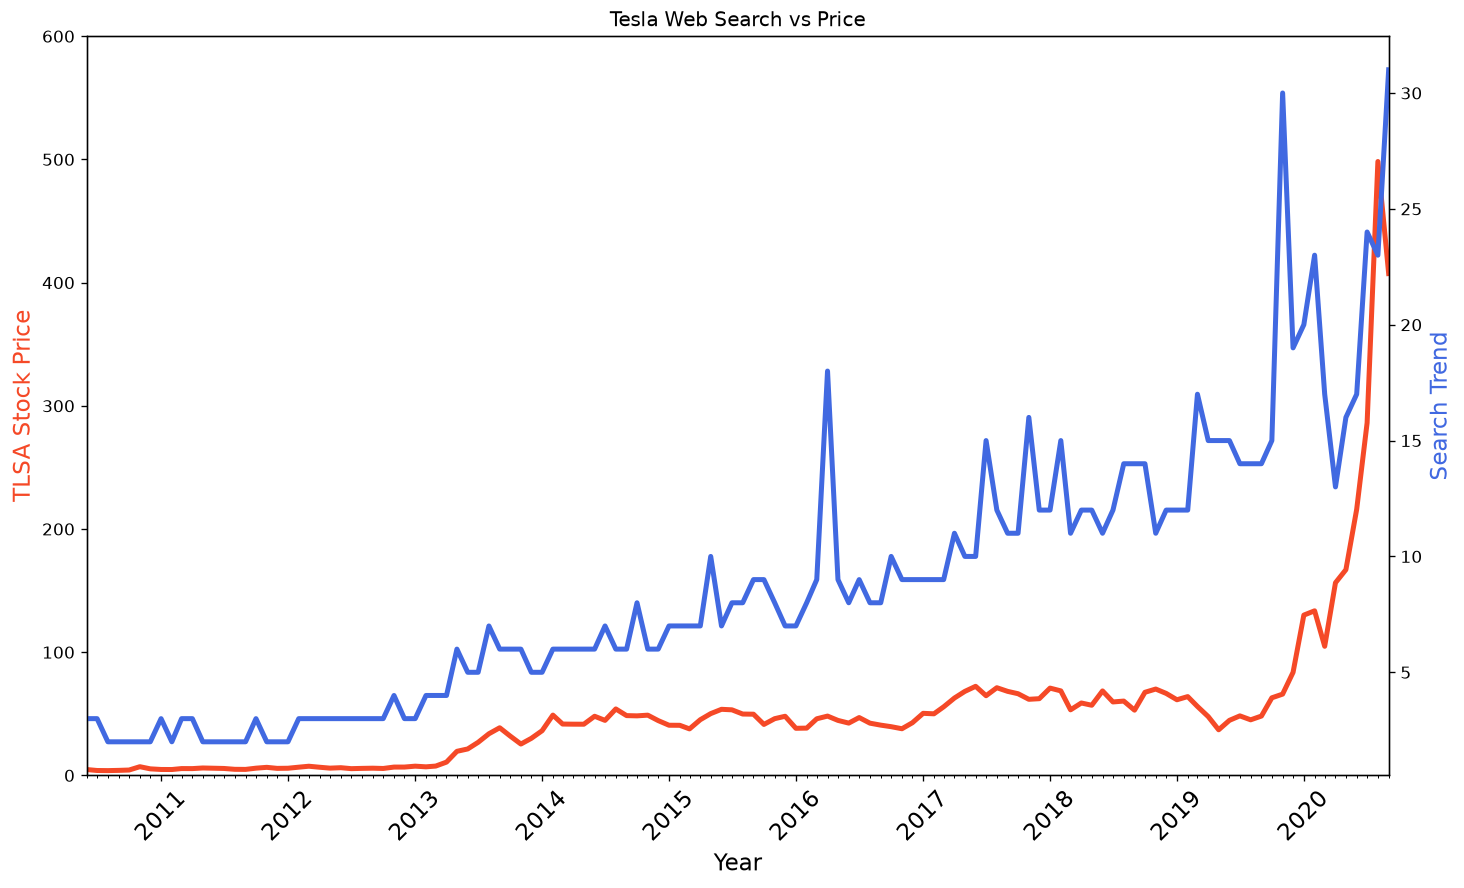

In [121]:
# Create locators for ticks on the time axis
df_tesla.head()

# Increase the figure size (e.g., to 14 by 8).
# Keep the chart looking sharp by changing the dots-per-inch or DPI value.
pyplot.figure(figsize=(14, 8), dpi=120)

# Increase the font sizes for the labels and the ticks on the x-axis to 14.
# Rotate the text on the x-axis by 45 degrees.
pyplot.xticks(fontsize=14, rotation=45)
pyplot.yticks()

# Add a title that reads 'Tesla Web Search vs Price'
pyplot.title('Tesla Web Search vs Price')

ax1 = pyplot.gca()
ax2 = ax1.twinx()

# Make the lines on the chart thicker.
ax1.plot(df_tesla.MONTH, df_tesla['TSLA_USD_CLOSE'], linewidth=3, color='#F54927')
ax2.plot(df_tesla.MONTH, df_tesla['TSLA_WEB_SEARCH'], linewidth=3, color='royalblue')

years = dates.YearLocator()
months = dates.MonthLocator()
years_fmt = dates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.set_xlabel('Year', fontsize=14,)
ax1.set_ylabel('TLSA Stock Price', fontsize=14, color='#F54927')
ax2.set_ylabel('Search Trend', fontsize=14, color='royalblue')

# Set minimum and maximum values for the y and x-axis. Hint: check out methods like set_xlim().
ax1.set_ylim([0, 600])
ax1.set_xlim(left=df_tesla.MONTH.min(), right=df_tesla.MONTH.max())

# Finally use plt.show() to display the chart below the cell instead of relying on the automatic notebook output.
pyplot.show()

years = dates.YearLocator()
months = dates.MonthLocator()
years_fmt = dates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)




In [122]:
# Register date converters to avoid warning messages

### Tesla Stock Price v.s. Search Volume

**Challenge:** Plot the Tesla stock price against the Tesla search volume using a line chart and two different axes. Label one axis 'TSLA Stock Price' and the other 'Search Trend'. 

Text(0, 0.5, 'Search Trend')

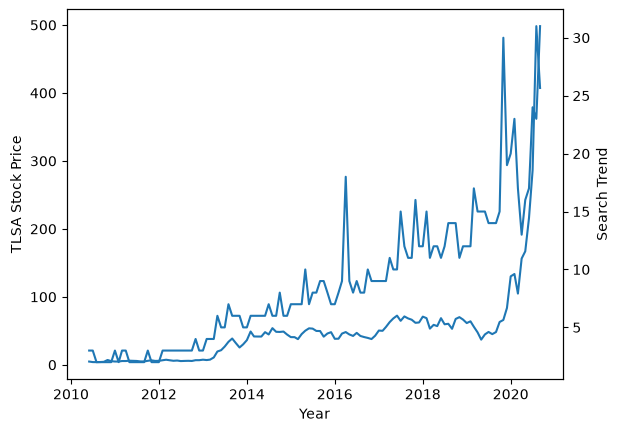

In [123]:
# Create locators for ticks on the time axis
df_tesla.head()

ax1 = pyplot.gca()
ax2 = ax1.twinx()

# Make the lines on the chart thicker.
ax1.plot(df_tesla.MONTH, df_tesla['TSLA_USD_CLOSE'])
ax2.plot(df_tesla.MONTH, df_tesla['TSLA_WEB_SEARCH'])

ax1.set_xlabel('Year')
ax1.set_ylabel('TLSA Stock Price')
ax2.set_ylabel('Search Trend')

**Challenge**: Add colours to style the chart. This will help differentiate the two lines and the axis labels. Try using one of the blue [colour names](https://matplotlib.org/3.1.1/gallery/color/named_colors.html) for the search volume and a HEX code for a red colour for the stock price. 
<br>
<br>
Hint: you can colour both the [axis labels](https://matplotlib.org/3.3.2/api/text_api.html#matplotlib.text.Text) and the [lines](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.lines.Line2D.html#matplotlib.lines.Line2D) on the chart using keyword arguments (kwargs).  

Text(0, 0.5, 'Search Trend')

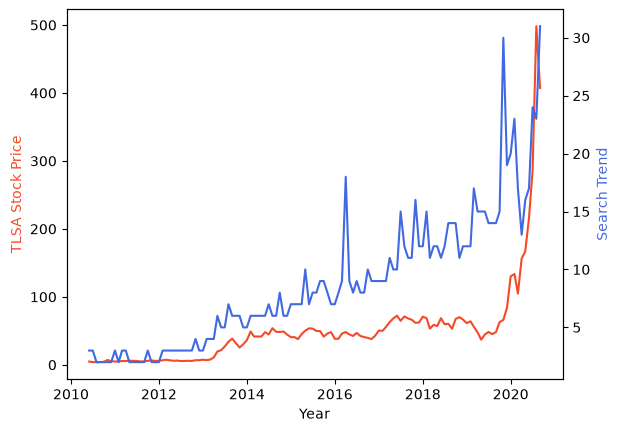

In [124]:
# Create locators for ticks on the time axis
df_tesla.head()

ax1 = pyplot.gca()
ax2 = ax1.twinx()

# Make the lines on the chart thicker.
ax1.plot(df_tesla.MONTH, df_tesla['TSLA_USD_CLOSE'], color='#F54927')
ax2.plot(df_tesla.MONTH, df_tesla['TSLA_WEB_SEARCH'], color='royalblue')

ax1.set_xlabel('Year')
ax1.set_ylabel('TLSA Stock Price', color='#F54927')
ax2.set_ylabel('Search Trend', color='royalblue')


**Challenge**: Make the chart larger and easier to read. 
1. Increase the figure size (e.g., to 14 by 8). 
2. Increase the font sizes for the labels and the ticks on the x-axis to 14. 
3. Rotate the text on the x-axis by 45 degrees. 
4. Make the lines on the chart thicker. 
5. Add a title that reads 'Tesla Web Search vs Price'
6. Keep the chart looking sharp by changing the dots-per-inch or [DPI value](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.figure.html). 
7. Set minimum and maximum values for the y and x axis. Hint: check out methods like [set_xlim()](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.set_xlim.html). 
8. Finally use [plt.show()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.show.html) to display the chart below the cell instead of relying on the automatic notebook output.

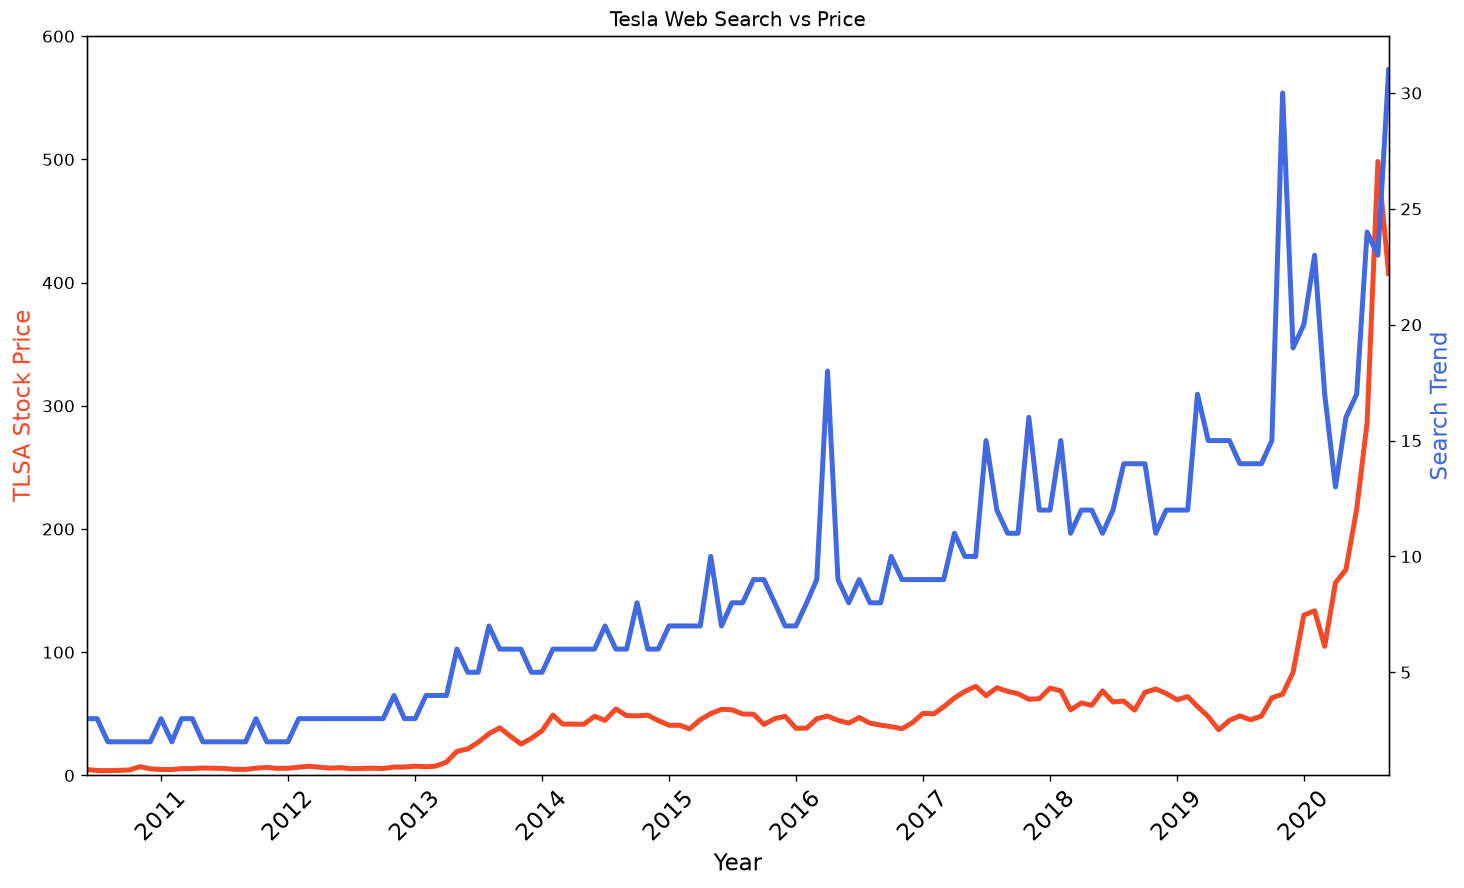

In [125]:
# Create locators for ticks on the time axis
df_tesla.head()

# Increase the figure size (e.g., to 14 by 8).
# Keep the chart looking sharp by changing the dots-per-inch or DPI value.
pyplot.figure(figsize=(14, 8), dpi=120)

# Increase the font sizes for the labels and the ticks on the x-axis to 14.
# Rotate the text on the x-axis by 45 degrees.
pyplot.xticks(fontsize=14, rotation=45)
pyplot.yticks()

# Add a title that reads 'Tesla Web Search vs Price'
pyplot.title('Tesla Web Search vs Price')

ax1 = pyplot.gca()
ax2 = ax1.twinx()

# Make the lines on the chart thicker.
ax1.plot(df_tesla.MONTH, df_tesla['TSLA_USD_CLOSE'], linewidth=3, color='#F54927')
ax2.plot(df_tesla.MONTH, df_tesla['TSLA_WEB_SEARCH'], linewidth=3, color='royalblue')

ax1.set_xlabel('Year', fontsize=14,)
ax1.set_ylabel('TLSA Stock Price', fontsize=14, color='#F54927')
ax2.set_ylabel('Search Trend', fontsize=14, color='royalblue')

# Set minimum and maximum values for the y and x-axis. Hint: check out methods like set_xlim().
ax1.set_ylim([0, 600])
ax1.set_xlim(left=df_tesla.MONTH.min(), right=df_tesla.MONTH.max())

# Finally use plt.show() to display the chart below the cell instead of relying on the automatic notebook output.
pyplot.show()

How to add tick formatting for dates on the x-axis. 

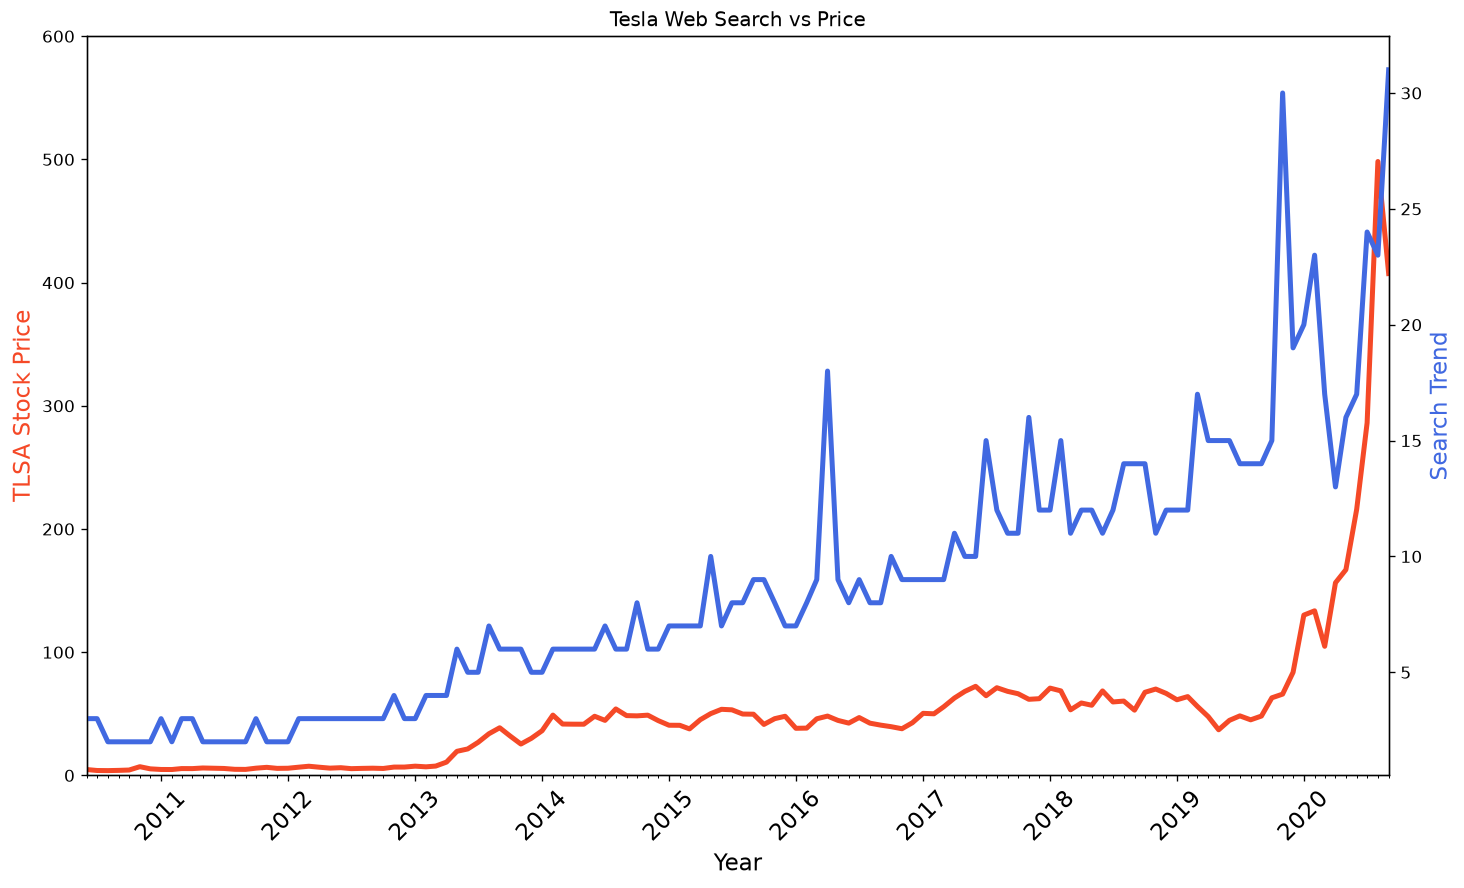

In [126]:
# Create locators for ticks on the time axis
df_tesla.head()

# Increase the figure size (e.g., to 14 by 8).
# Keep the chart looking sharp by changing the dots-per-inch or DPI value.
pyplot.figure(figsize=(14, 8), dpi=120)

# Increase the font sizes for the labels and the ticks on the x-axis to 14.
# Rotate the text on the x-axis by 45 degrees.
pyplot.xticks(fontsize=14, rotation=45)
pyplot.yticks()

# Add a title that reads 'Tesla Web Search vs Price'
pyplot.title('Tesla Web Search vs Price')

ax1 = pyplot.gca()
ax2 = ax1.twinx()

# Make the lines on the chart thicker.
ax1.plot(df_tesla.MONTH, df_tesla['TSLA_USD_CLOSE'], linewidth=3, color='#F54927')
ax2.plot(df_tesla.MONTH, df_tesla['TSLA_WEB_SEARCH'], linewidth=3, color='royalblue')

# When working with time series, it's often quite difficult to get the tick marks on 
# charts looking the way you want to. This is why we have Locator helpers.
# Using Locators we can change our x-axis

years = dates.YearLocator()
months = dates.MonthLocator()
years_fmt = dates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

# Styling
ax1.set_xlabel('Year', fontsize=14,)
ax1.set_ylabel('TLSA Stock Price', fontsize=14, color='#F54927')
ax2.set_ylabel('Search Trend', fontsize=14, color='royalblue')

# Set minimum and maximum values for the y and x-axis. Hint: check out methods like set_xlim().
ax1.set_ylim([0, 600])
ax1.set_xlim(left=df_tesla.MONTH.min(), right=df_tesla.MONTH.max())

# Finally use plt.show() to display the chart below the cell instead of relying on the automatic notebook output.
pyplot.show()

### Bitcoin (BTC) Price v.s. Search Volume

**Challenge**: Create the same chart for the Bitcoin Prices vs. Search volumes. <br>
1. Modify the chart title to read 'Bitcoin News Search vs Resampled Price' <br>
2. Change the y-axis label to 'BTC Price' <br>
3. Change the y- and x-axis limits to improve the appearance <br>
4. Investigate the [linestyles](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html ) to make the BTC price a dashed line <br>
5. Investigate the [marker types](https://matplotlib.org/3.2.1/api/markers_api.html) to make the search datapoints little circles <br>
6. Were big increases in searches for Bitcoin accompanied by big increases in the price?

In [127]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0


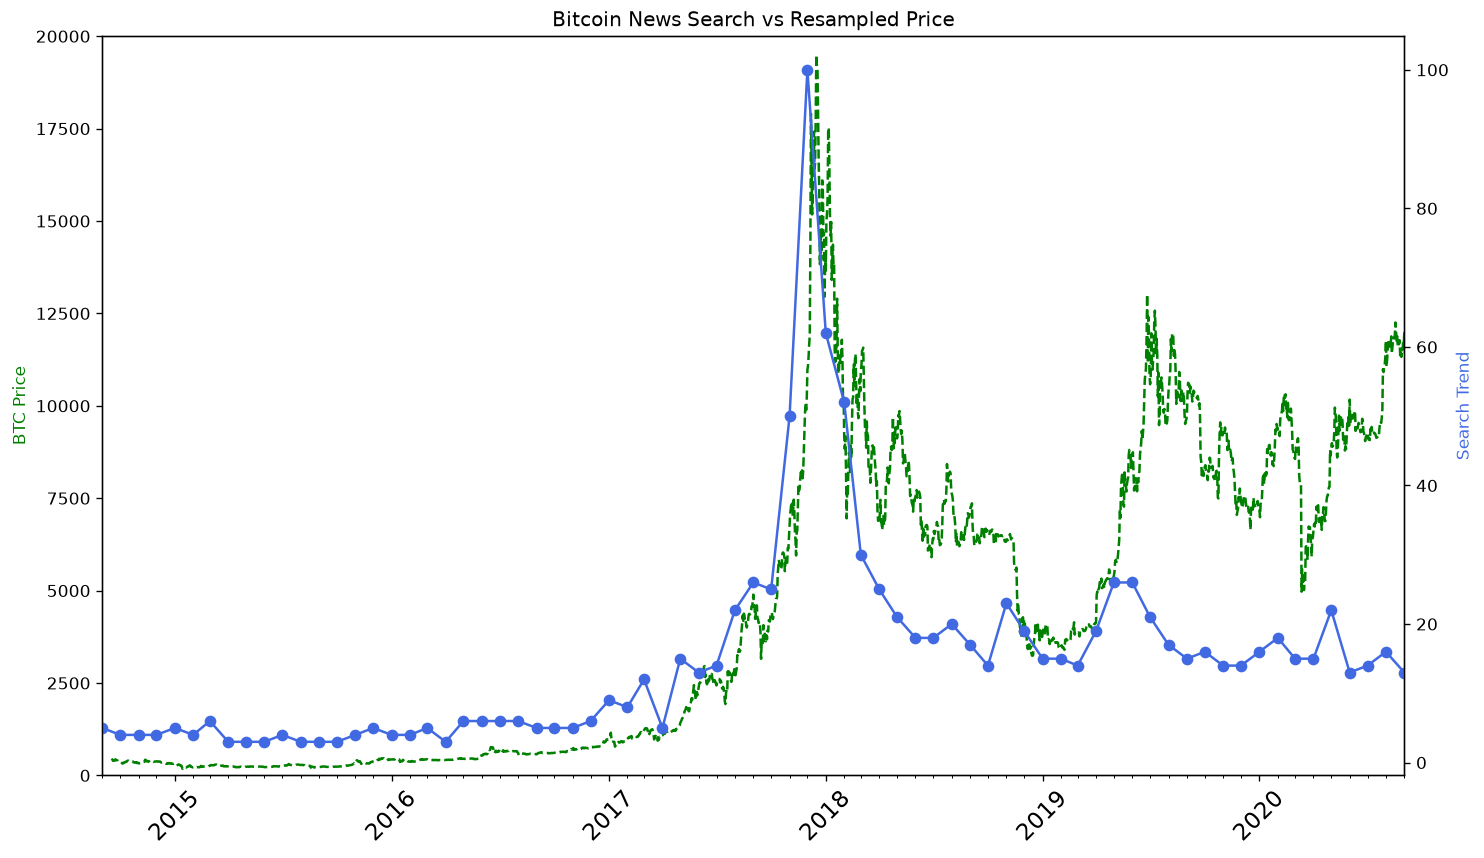

In [128]:
pyplot.figure(figsize=(14, 8), dpi=120)

pyplot.xticks(fontsize=14, rotation=45)

ax1 = pyplot.gca()
ax2 = ax1.twinx()

# Investigate the linestyles to make the BTC closing price a dashed line
ax1.plot(df_btc_price.DATE, df_btc_price['CLOSE'], linewidth=1.5, color='green', linestyle='dashed')

# Investigate the marker types to make the search datapoints little circles
ax2.plot(df_btc_search.MONTH, df_btc_search['BTC_NEWS_SEARCH'], linewidth=1.5, color='royalblue', marker='o')

# Modify the chart title to read 'Bitcoin News Search vs Resampled Price'
pyplot.title('Bitcoin News Search vs Resampled Price')

# Change the y-axis label to 'BTC Price'
ax1.set_ylabel('BTC Price', color='green')
ax2.set_ylabel('Search Trend', color='royalblue')

# Change the y- and x-axis limits to improve the appearance
ax1.set_ylim([0, 20000])
ax1.set_xlim([df_btc_search.MONTH.min(), df_btc_search.MONTH.max()])

years = dates.YearLocator()
months = dates.MonthLocator()
years_fmt = dates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)




### Unemployement Benefits Search vs. Actual Unemployment in the U.S.

**Challenge** Plot the search for "unemployment benefits" against the unemployment rate. 
1. Change the title to: Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate <br>
2. Change the y-axis label to: FRED U/E Rate <br>
3. Change the axis limits <br>
4. Add a grey [grid](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.grid.html) to the chart to better see the years and the U/E rate values. Use dashes for the line style<br> 
5. Can you discern any seasonality in the searches? Is there a pattern? 

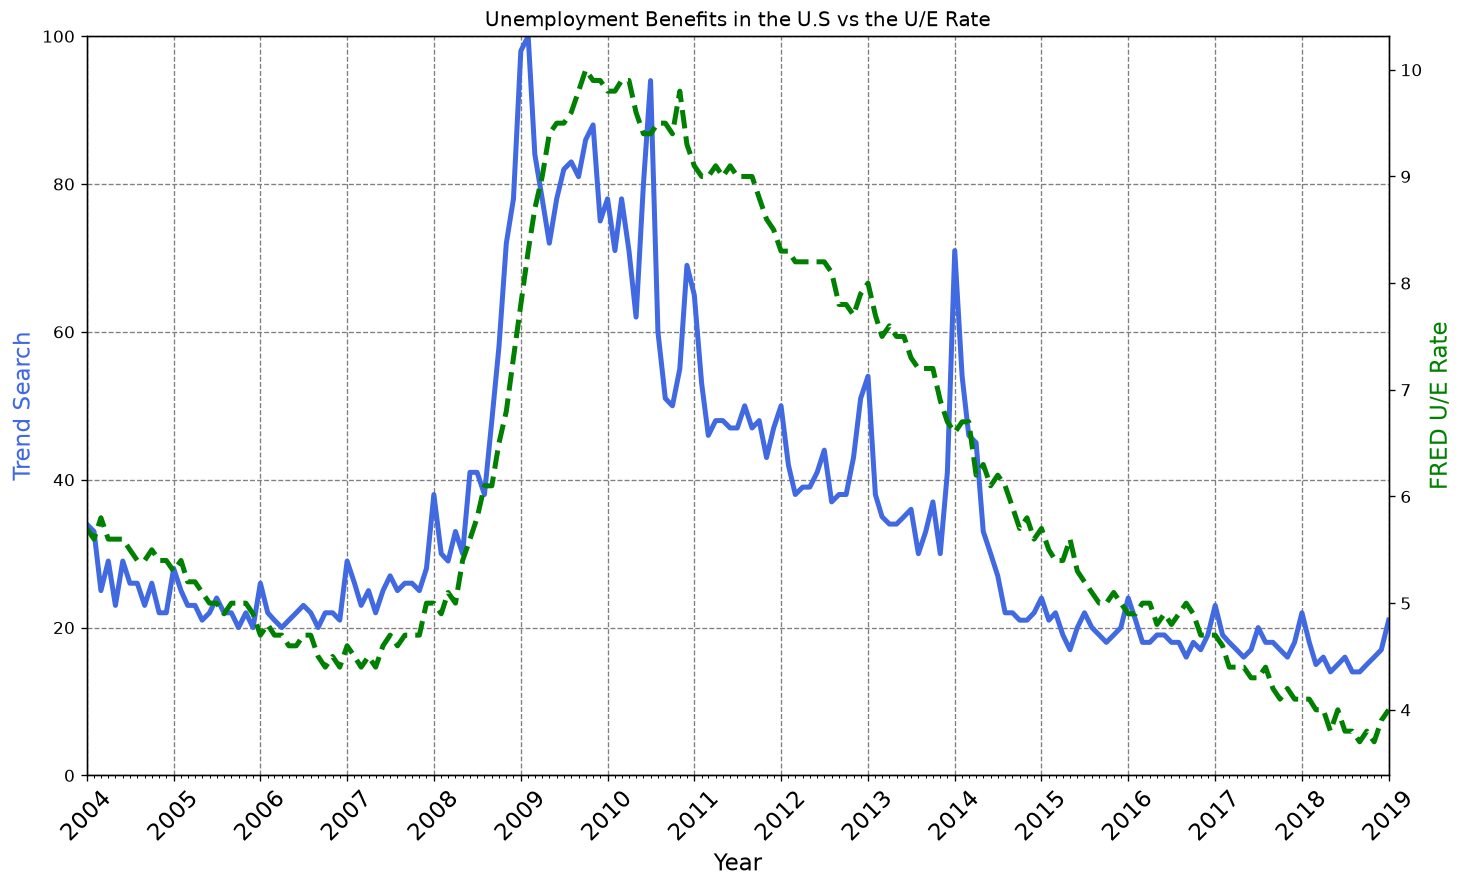

In [144]:
# Can you discern any seasonality in the searches? Is there a pattern?

pyplot.figure(figsize=(14, 8), dpi=120)
pyplot.xticks(fontsize=14, rotation=45)

# Add a grey grid to the chart to better see the years and the U/E rate values. Use dashed lines for the line style.
pyplot.grid(color='gray', linestyle='--')

# Change the title to: Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate
pyplot.title('Unemployment Benefits in the U.S vs the U/E Rate')

ax1 = pyplot.gca()
ax2 = ax1.twinx()

ax1.plot(df_unemployment.MONTH, df_unemployment['UE_BENEFITS_WEB_SEARCH'], linewidth=3, color='royalblue')

# Change the y-axis label to: FRED U/E Rate
ax2.plot(df_unemployment.MONTH, df_unemployment['UNRATE'], linewidth=3, color='green', linestyle='--')

ax1.set_xlabel('Year', fontsize=14,)
ax1.set_ylabel('Trend Search', fontsize=14, color='royalblue')
ax2.set_ylabel('FRED U/E Rate', fontsize=14, color='green')

# Change the axis limits
ax1.set_ylim(bottom=0, top=100)
ax1.set_xlim(left=df_unemployment.MONTH.min(), right=df_unemployment.MONTH.max())

years = dates.YearLocator()
months = dates.MonthLocator()
years_fmt = dates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

pyplot.show()

**Challenge**: Calculate the 3-month or 6-month rolling average for the web searches. Plot the 6-month rolling average search data against the actual unemployment. What do you see in the chart? Which line moves first?


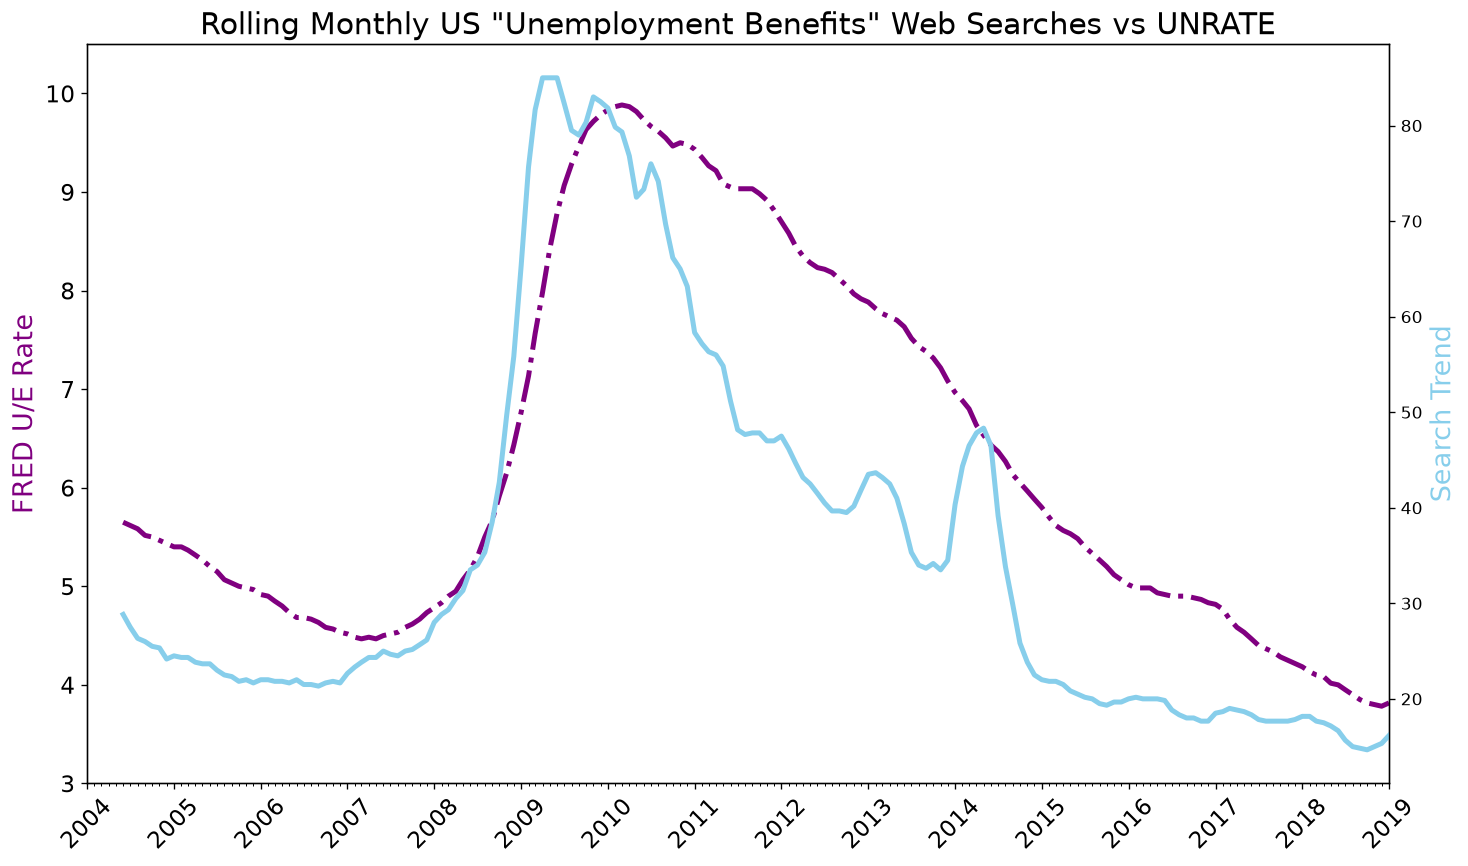

In [147]:
pyplot.figure(figsize=(14,8), dpi=120)
pyplot.title('Rolling Monthly US "Unemployment Benefits" Web Searches vs UNRATE', fontsize=18)
pyplot.yticks(fontsize=14)
pyplot.xticks(fontsize=14, rotation=45)
 
ax1 = pyplot.gca()
ax2 = ax1.twinx()
 
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)
 
ax1.set_ylabel('FRED U/E Rate', color='purple', fontsize=16)
ax2.set_ylabel('Search Trend', color='skyblue', fontsize=16)
 
ax1.set_ylim(bottom=3, top=10.5)
ax1.set_xlim([df_unemployment.MONTH[0], df_unemployment.MONTH.max()])
 
# Calculate the rolling average over a 6 month window
roll_df = df_unemployment[['UE_BENEFITS_WEB_SEARCH', 'UNRATE']].rolling(window=6).mean()
 
ax1.plot(df_unemployment.MONTH, roll_df.UNRATE, 'purple', linewidth=3, linestyle='-.')
ax2.plot(df_unemployment.MONTH, roll_df.UE_BENEFITS_WEB_SEARCH, 'skyblue', linewidth=3)
 
pyplot.show()

### Including 2020 in Unemployment Charts

**Challenge**: Read the data in the 'UE Benefits Search vs UE Rate 2004-20.csv' into a DataFrame. Convert the MONTH column to Pandas Datetime objects and then plot the chart. What do you see?

In [ ]:
df_unemployment_2 = pandas.read_csv('UE Benefits Search vs UE Rate 2004-20.csv')
df_unemployment.describe()
df_unemployment_2.MONTH = pandas.to_datetime(df_unemployment_2.MONTH)


pandas.Timestamp

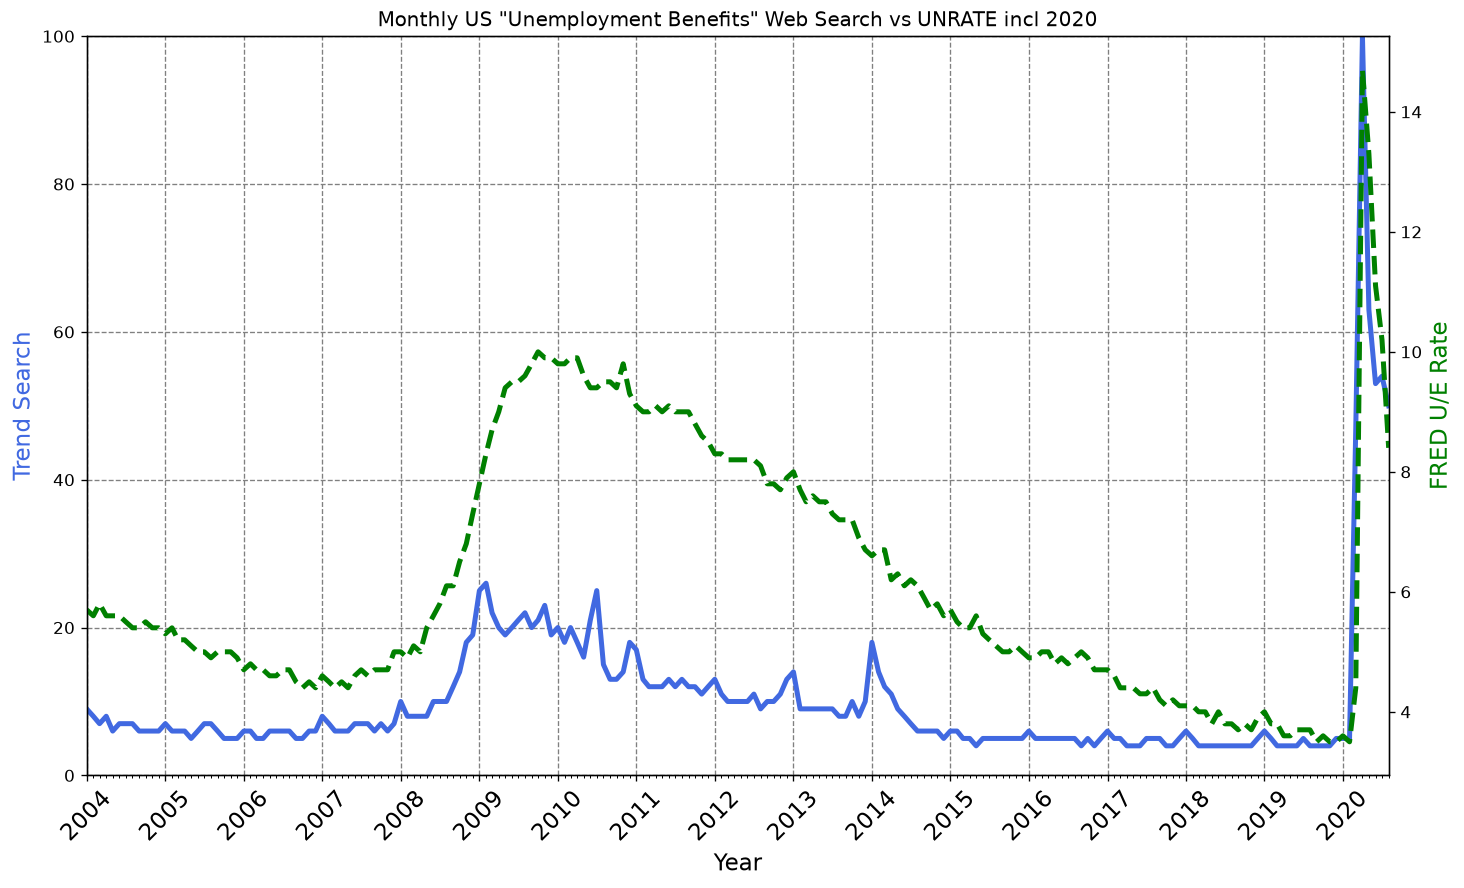

In [157]:
# Can you discern any seasonality in the searches? Is there a pattern?

pyplot.figure(figsize=(14, 8), dpi=120)
pyplot.xticks(fontsize=14, rotation=45)

# Add a grey grid to the chart to better see the years and the U/E rate values. Use dashed lines for the line style.
pyplot.grid(color='gray', linestyle='--')

# Change the title to: Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate
pyplot.title('Monthly US "Unemployment Benefits" Web Search vs UNRATE incl 2020')

ax1 = pyplot.gca()
ax2 = ax1.twinx()

ax1.plot(df_unemployment_2.MONTH, df_unemployment_2['UE_BENEFITS_WEB_SEARCH'], linewidth=3, color='royalblue')

# Change the y-axis label to: FRED U/E Rate
ax2.plot(df_unemployment_2.MONTH, df_unemployment_2['UNRATE'], linewidth=3, color='green', linestyle='--')

ax1.set_xlabel('Year', fontsize=14,)
ax1.set_ylabel('Trend Search', fontsize=14, color='royalblue')
ax2.set_ylabel('FRED U/E Rate', fontsize=14, color='green')

# Change the axis limits
ax1.set_ylim(bottom=0, top=100)
ax1.set_xlim(left=df_unemployment_2.MONTH.min(), right=df_unemployment_2.MONTH.max())

years = dates.YearLocator()
months = dates.MonthLocator()
years_fmt = dates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

pyplot.show()